# Multiple random variables

#### Notebook setup

We'll start by importing the Python modules we'll need for this notebook.

In [1]:
# load Python modules
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Figures setup
plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={"font.family": "serif",
        "font.serif": ["Palatino", "DejaVu Serif", "serif"],
        "figure.figsize": (4.5, 1.5)},
)
%config InlineBackend.figure_format = "retina"

# Where to store figures
DESTDIR = "figures/prob/multiple_continuous"

from ministats.utils import savefigure

<Figure size 640x480 with 0 Axes>

In [3]:
from ministats import plot_pdf_and_cdf

In [4]:
# set random seed for repeatability
np.random.seed(3)

### Joint probability density functions

In [5]:
from scipy.stats import multivariate_normal

# parameters
mu = [10, 5]
Sigma = [[  3**2,     0.75*3*1],
         [  0.75*3*1,     1**2]]


# multivariate normal
rvXY = multivariate_normal(mu, Sigma)

Saved figure to figures/prob/multiple_continuous/joint_prob_density_fXY_in_3D.pdf
Saved figure to figures/prob/multiple_continuous/joint_prob_density_fXY_in_3D.png


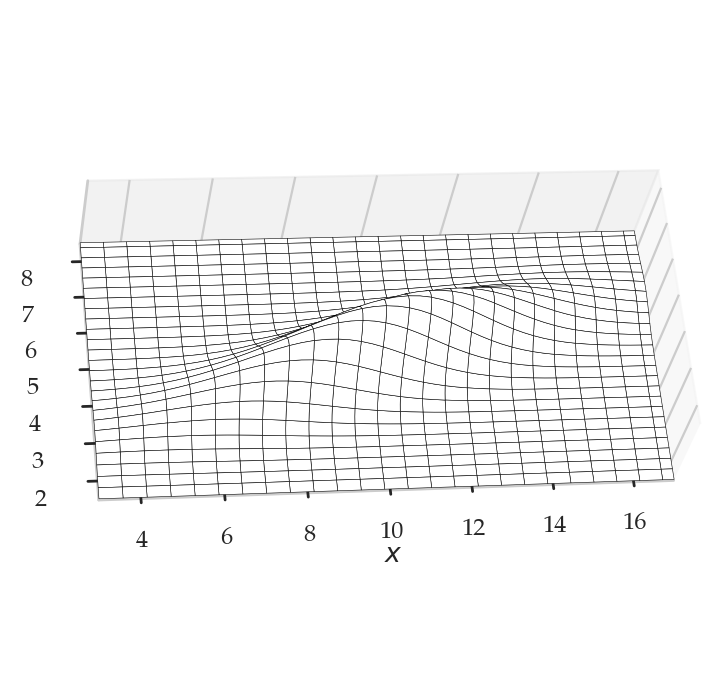

In [6]:
from ministats import plot_joint_pdf_surface

xmin = 3
xmax = 17
ymin = 1.5
ymax = 8.5

fig = plt.figure(figsize=(3.5,3.5))
viewdict = dict(elev=60., azim=-110, roll=-16)
ax = plot_joint_pdf_surface(rvXY, xlims=[xmin,xmax], ylims=[ymin,ymax], fig=fig, viewdict=viewdict, ngrid=50);

filename = os.path.join(DESTDIR, "joint_prob_density_fXY_in_3D.pdf")
savefigure(ax, filename)

Saved figure to figures/prob/multiple_continuous/joint_prob_density_fXY.pdf
Saved figure to figures/prob/multiple_continuous/joint_prob_density_fXY.png


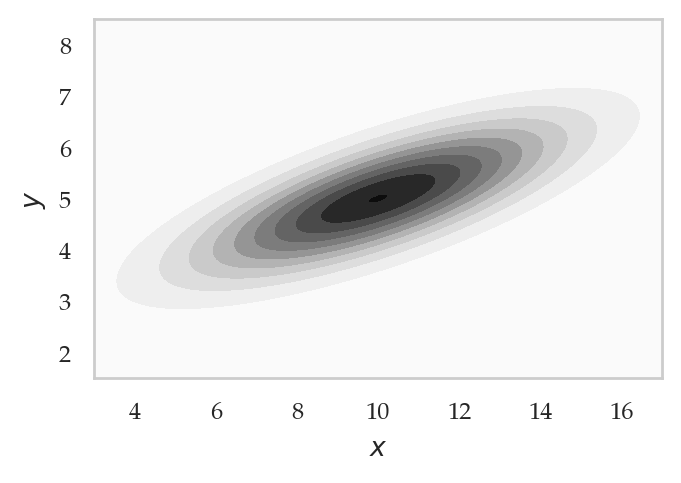

In [7]:
from ministats import plot_joint_pdf_contourf

fig, ax = plt.subplots(figsize=(3.5,2.5))
plot_joint_pdf_contourf(rvXY, xlims=[xmin,xmax], ylims=[ymin,ymax], ax=ax)
filename = os.path.join(DESTDIR, "joint_prob_density_fXY.pdf")
savefigure(ax, filename)

Saved figure to figures/prob/multiple_continuous/joint_prob_density_fXY_event_highlight.pdf
Saved figure to figures/prob/multiple_continuous/joint_prob_density_fXY_event_highlight.png


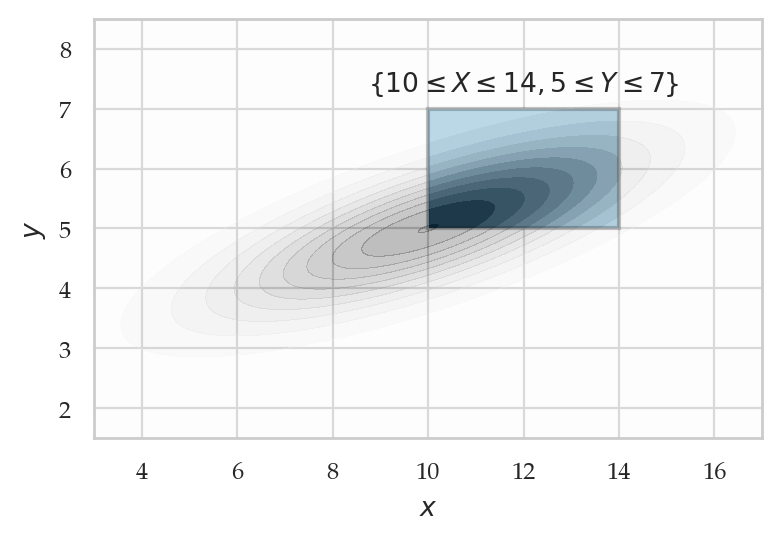

In [8]:
fig, ax = plt.subplots(figsize=(4,2.8))
event = [(10,5), (14,7)]
plot_joint_pdf_contourf(rvXY, xlims=[xmin,xmax], ylims=[ymin,ymax], ax=ax, highlight=[event]);
ax.text(12, 7.3, r"$\{10 \leq X \leq 14, 5 \leq Y \leq 7\}$", ha="center")
filename = os.path.join(DESTDIR, "joint_prob_density_fXY_event_highlight.pdf")
savefigure(ax, filename)

### Marginal density functions

Saved figure to figures/prob/multiple_continuous/joint_prob_density_fXY_with_marginals.pdf
Saved figure to figures/prob/multiple_continuous/joint_prob_density_fXY_with_marginals.png


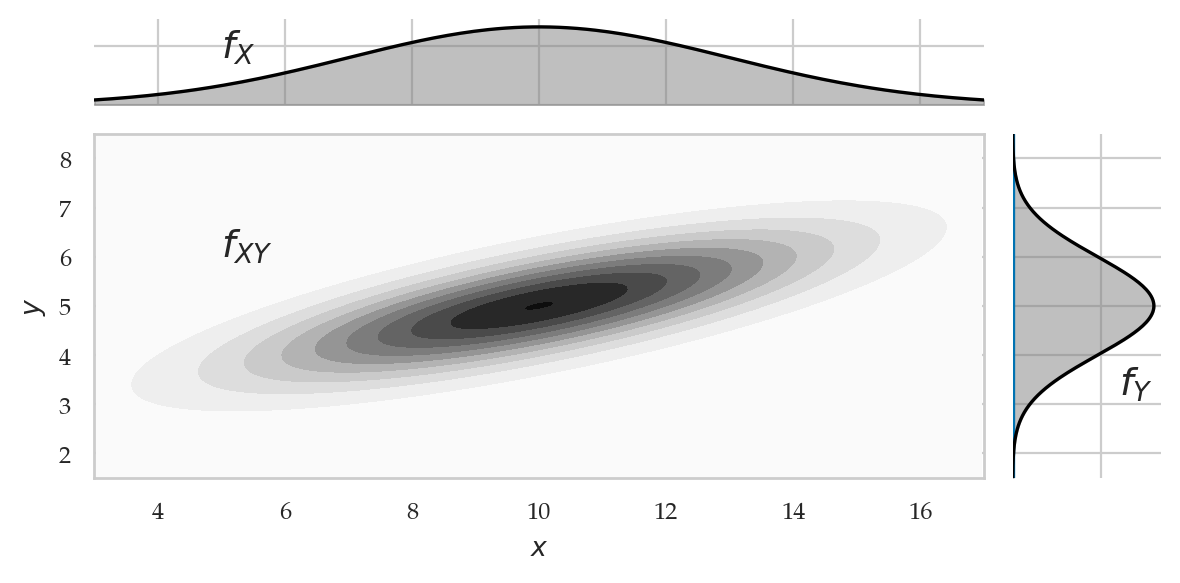

In [9]:
from ministats.book.figures import plot_joint_pdf_and_marginals

fig = plt.figure(figsize=(6,3))
plot_joint_pdf_and_marginals(rvXY, xlims=[xmin,xmax], ylims=[ymin,ymax], fig=fig)
filename = os.path.join(DESTDIR, "joint_prob_density_fXY_with_marginals.pdf")
savefigure(fig, filename)

### Conditional probability density functions

Saved figure to figures/prob/multiple_continuous/slices_from_fXY.pdf
Saved figure to figures/prob/multiple_continuous/slices_from_fXY.png


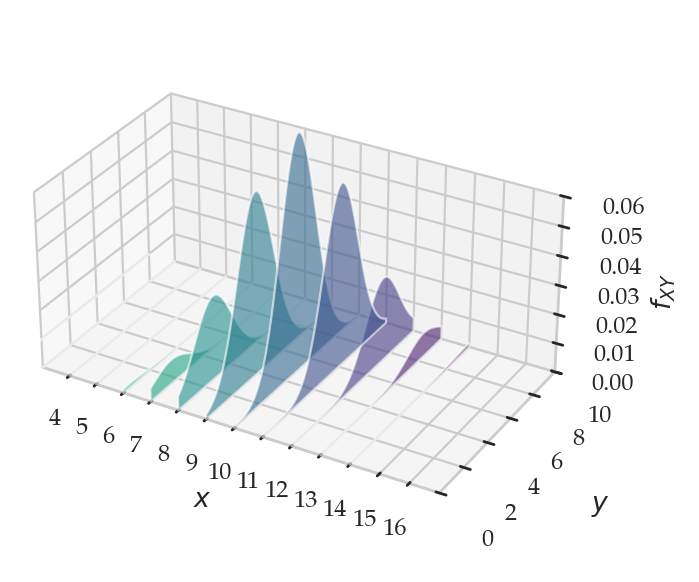

In [10]:
from ministats.book.figures import plot_slices_through_joint_pdf

fig = plt.figure(figsize=(6,3))
xcuts = range(2, 15, 1)
plot_slices_through_joint_pdf(rvXY, xlims=[3,17], ylims=[0,10], xcuts=xcuts, fig=fig);
ax = fig.axes[0]
ax.text2D(1.19, 0.5, "$f_{XY}$", transform=ax.transAxes,
          fontsize=plt.rcParams["axes.labelsize"],
          rotation=90, va="center", ha="center");

filename = os.path.join(DESTDIR, "slices_from_fXY.pdf")
savefigure(fig, filename)

Saved figure to figures/prob/multiple_continuous/conditional_distributions_fYgivenX.pdf
Saved figure to figures/prob/multiple_continuous/conditional_distributions_fYgivenX.png


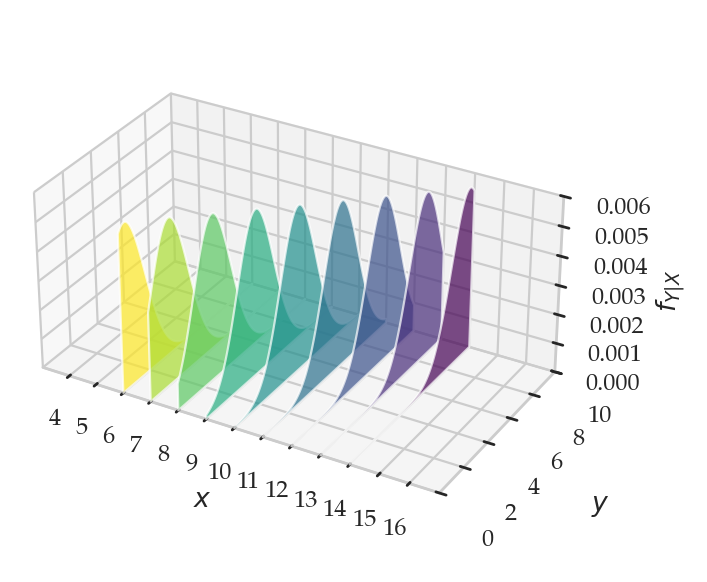

In [11]:
from ministats.book.figures import plot_conditional_fYgivenX

fig = plt.figure(figsize=(6,3))
xcuts = range(6, 15, 1)
plot_conditional_fYgivenX(rvXY, xlims=[3,17], ylims=[0,10], xcuts=xcuts, fig=fig);
ax = fig.axes[0]
ax.text2D(1.2, 0.5, "$f_{Y|X}$", transform=ax.transAxes,
          fontsize=plt.rcParams["axes.labelsize"],
          rotation=90, va="center", ha="center");

filename = os.path.join(DESTDIR, "conditional_distributions_fYgivenX.pdf")
savefigure(fig, filename)

## Example 2: bivariate uniform over a triangle

In [12]:
from ministats.probs import BivariateUniformOnTriangle

rvXY2 = BivariateUniformOnTriangle()

Saved figure to figures/prob/multiple_continuous/joint_prob_density_triangle_fXY2_in_3D.pdf
Saved figure to figures/prob/multiple_continuous/joint_prob_density_triangle_fXY2_in_3D.png


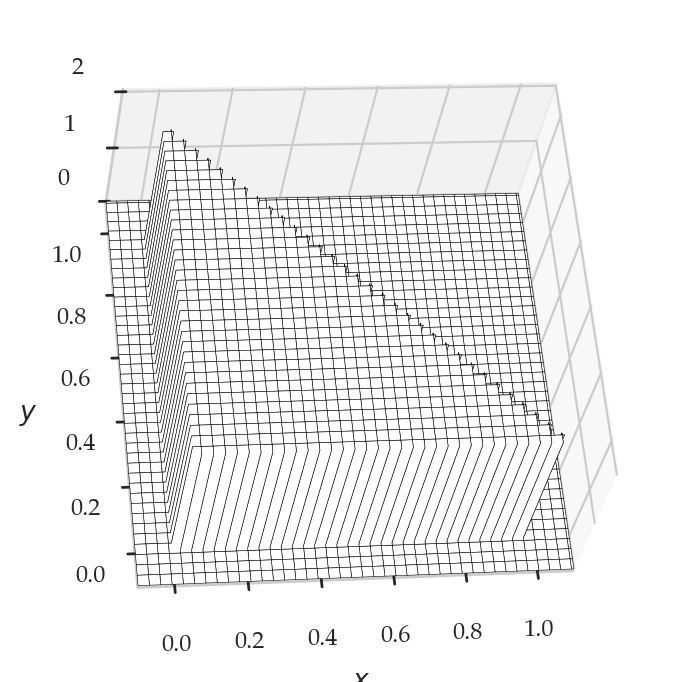

In [13]:
fig = plt.figure(figsize=(3.5,3.5))
viewdict = dict(elev=60., azim=-110, roll=-16)
ax = plot_joint_pdf_surface(
    rvXY2,
    xlims=(-0.1, 1.1),
    ylims=(-0.1, 1.1),
    ngrid=2001,
    viewdict=viewdict,
    box_aspect=(1, 1, 0.5),
    fig=fig,
)
ax.set_zticks([0,1,2])

filename = os.path.join(DESTDIR, "joint_prob_density_triangle_fXY2_in_3D.pdf")
savefigure(ax, filename)

Saved figure to figures/prob/multiple_continuous/joint_prob_density_triangle_fXY2.pdf
Saved figure to figures/prob/multiple_continuous/joint_prob_density_triangle_fXY2.png


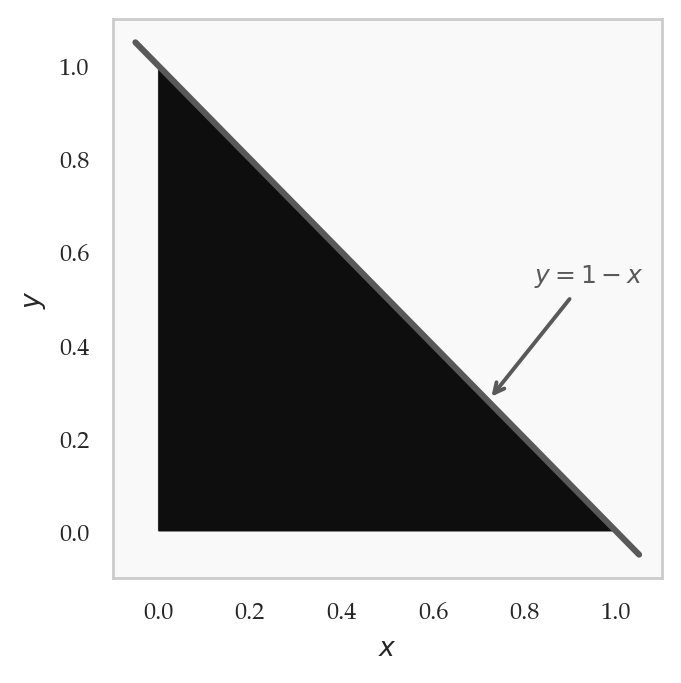

In [14]:
fig, ax = plt.subplots(figsize=(3.5,3.5))
plot_joint_pdf_contourf(
    rvXY2,
    xlims=(-0.1, 1.1),
    ylims=(-0.1, 1.1),
    ngrid=401,
    ax=ax,
)


# Add boundary line y = 1 - x
xline = np.linspace(-0.05, 1.05, 200)
yline = 1 - xline

ax.plot(
    xline, yline,
    color="0.35",
    linewidth=2.2,
    zorder=10,
)

# Horizontal label on the side with arrow
ax.annotate(
    r"$y = 1 - x$",
    xy=(0.72, 0.28),          # point on the line
    xytext=(0.82, 0.55),      # label position
    color="0.35",
    fontsize=9,
    ha="left",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        color="0.35",
        lw=1.4,
        shrinkA=2,
        shrinkB=2,
    ),
    zorder=11,
)

filename = os.path.join(DESTDIR, "joint_prob_density_triangle_fXY2.pdf")
savefigure(ax, filename)

### Examples

#### Example ?: Multivariate normal

In [15]:
# TODO

### Useful probability formulas

### Multivariable expectation
                                

### Independent, identically distributed random variabls